# Hyperspectral Image Classification with CNN and Transformer

**Author:** Alessandro Carotenuto  
**Student ID:** 1847282  
**Dataset:** Pavia University  

## Project aim

The project aims to classify land-cover pixels in a hyperspectral image.
A spatial-spectral patch centered on each labeled pixel is used as input.
A CNN learns local features, while a lightweight Transformer models non-local context.

## Setup 

### Experiment Configuration

In [ ]:
# Standard library imports
from pathlib import Path
import sys

# Third-party imports
import numpy as np
import torch
import torch.nn as nn
from scipy.io import loadmat

# Project paths and local imports
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from data import (
    collect_coordinates_by_class,
    count_padding_requirements,
    create_dataloaders,
    create_few_shot_split,
    create_patch_datasets,
    extract_patch,
    normalize_per_band_min_max,
    reflect_pad_spatially,
    save_and_verify_split,
    split_counts_by_class,
    verify_few_shot_split,
)
from evaluation import (
    build_classification_map,
    build_evaluation_report,
    evaluate_checkpoint,
    save_evaluation_report,
)
from models import (
    ChannelAttention,
    ChannelSpatialAttentionBlock,
    CTBlock,
    MultiscaleCNNBlock,
    SpatialAttention,
    TransformerBranch,
    build_model,
)
from plotting import (
    plot_class_distribution,
    plot_classification_map,
    plot_confusion_matrix,
    plot_mean_spectral_signatures,
    plot_spectral_bands_and_ground_truth,
    plot_training_curves,
)
from training import (
    build_checkpoint_path,
    configure_reproducibility,
    fit_model,
    run_small_batch_overfit_check,
)
from utils import (
    ConformerCNNNormalization,
    DataSplitType,
    LRSchedulingType,
    ModelArchitecture,
    PatchSize,
    PaviaClass,
    RunMode,
    SplitName,
    TransformerPositionEncoding,
)

data_dir = project_root / "data" / "raw"
cube_path = data_dir / "PaviaU.mat"
ground_truth_path = data_dir / "PaviaU_gt.mat"

# Dataset and few-shot split
SPLIT_SEED = 42
DATA_SPLIT_TYPE = DataSplitType.RANDOM
TRAIN_SAMPLES_PER_CLASS = 10
VALIDATION_SAMPLES_PER_CLASS = 5
NUM_CLASSES = len(PaviaClass) - 1
LABELED_CLASS_IDS = tuple(
    int(label) for label in PaviaClass
    if label != PaviaClass.UNLABELED
)
SPLIT_NAMES = tuple(split_name.value for split_name in SplitName)
class_names = {
    int(label): label.display_name for label in PaviaClass
}

# Patch extraction and visualisation
PATCH_SIZE = PatchSize.PAPER
PATCH_RADIUS = int(PATCH_SIZE) // 2
BANDS_TO_SHOW = (10, 50, 90)

# Data loading
BATCH_SIZE = 32
NUM_WORKERS = 0
TRAINING_SEED = 100

# Model
ARCHITECTURE = ModelArchitecture.CNN_TRANSFORMER_CSA
MODEL_VARIANT = "outer_residual"
FEATURE_CHANNELS = 128
TRANSFORMER_HEADS = 4
TRANSFORMER_FFN_EXPANSION = 4
TRANSFORMER_FFN_RESIDUAL_SCALE = 0.5
TRANSFORMER_POSITION_ENCODING = TransformerPositionEncoding.LEARNED_2D
TRANSFORMER_CNN_NORMALIZATION = ConformerCNNNormalization.LAYER_NORM
TRANSFORMER_DROPOUT = 0.1

# Training
EPOCHS = 150
SMOKE_TEST_EPOCHS = 3
RUN_FULL_TRAINING = True
LEARNING_RATE = 0.00008
LR_SCHEDULING = LRSchedulingType.FIXED
EVALUATION_PROGRESS_EVERY = 100
SAVE_EVALUATION_REPORT = True

# Small-batch overfitting check
RUN_SMALL_BATCH_OVERFIT_TEST = False
OVERFIT_LEARNING_RATE = 0.003
OVERFIT_MIN_STEPS = 50
OVERFIT_MAX_STEPS = 250
OVERFIT_TARGET_LOSS = 0.05

print("Cube:", cube_path)
print("Ground truth:", ground_truth_path)
print("Patch size:", int(PATCH_SIZE))
print("Architecture:", ARCHITECTURE.display_name)
print("Model variant:", MODEL_VARIANT)
if ARCHITECTURE.uses_transformer:
    print("Transformer heads:", TRANSFORMER_HEADS)
    print(
        "Transformer FFN residual scale:",
        TRANSFORMER_FFN_RESIDUAL_SCALE,
    )
    print(
        "Transformer position encoding:",
        TRANSFORMER_POSITION_ENCODING.value,
    )
    print(
        "Transformer CNN normalization:",
        TRANSFORMER_CNN_NORMALIZATION.value,
    )
print("Split seed:", SPLIT_SEED)
print("Data split:", DATA_SPLIT_TYPE.value)
print("Training seed:", TRAINING_SEED)
print("Run mode:", RunMode.FULL if RUN_FULL_TRAINING else RunMode.SMOKE)

Cube: c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\raw\PaviaU.mat
Ground truth: c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\raw\PaviaU_gt.mat
Patch size: 15
Architecture: CNN-Transformer-CSA
Model variant: outer_residual_conformer_rpe
Transformer heads: 4
Transformer FFN residual scale: 0.5
Transformer position encoding: learned_2d
Split seed: 42
Data split: random
Training seed: 100
Run mode: full


### Loading MATLAB Files

In [2]:
cube_file = loadmat(cube_path)
ground_truth_file = loadmat(ground_truth_path)

print(cube_file.keys())
print(ground_truth_file.keys())

dict_keys(['__header__', '__version__', '__globals__', 'paviaU'])
dict_keys(['__header__', '__version__', '__globals__', 'paviaU_gt'])


### Dimension Check

In [3]:
cube = cube_file["paviaU"]
ground_truth = ground_truth_file["paviaU_gt"]

print("Cube:", cube.shape, cube.dtype)
print("Ground truth:", ground_truth.shape, ground_truth.dtype)
print("Cube range:", cube.min(), cube.max())
print("Labels:", np.unique(ground_truth))

Cube: (610, 340, 103) uint16
Ground truth: (610, 340) uint8
Cube range: 0 8000
Labels: [0 1 2 3 4 5 6 7 8 9]


### Class Count

In [4]:
labels, counts = np.unique(ground_truth, return_counts=True)

for label, count in zip(labels, counts):
    print(label, class_names[label], count)

0 Unlabeled 164624
1 Asphalt 6631
2 Meadows 18649
3 Gravel 2099
4 Trees 3064
5 Painted metal sheets 1345
6 Bare Soil 5029
7 Bitumen 1330
8 Self-Blocking Bricks 3682
9 Shadows 947


### Active Patch Shape

In [5]:
print("Patch size:", int(PATCH_SIZE))
print("Patch radius:", PATCH_RADIUS)

Patch size: 15
Patch radius: 7


## Dataset Exploration and Dataloaders

### Spectral Bands and Ground Truth

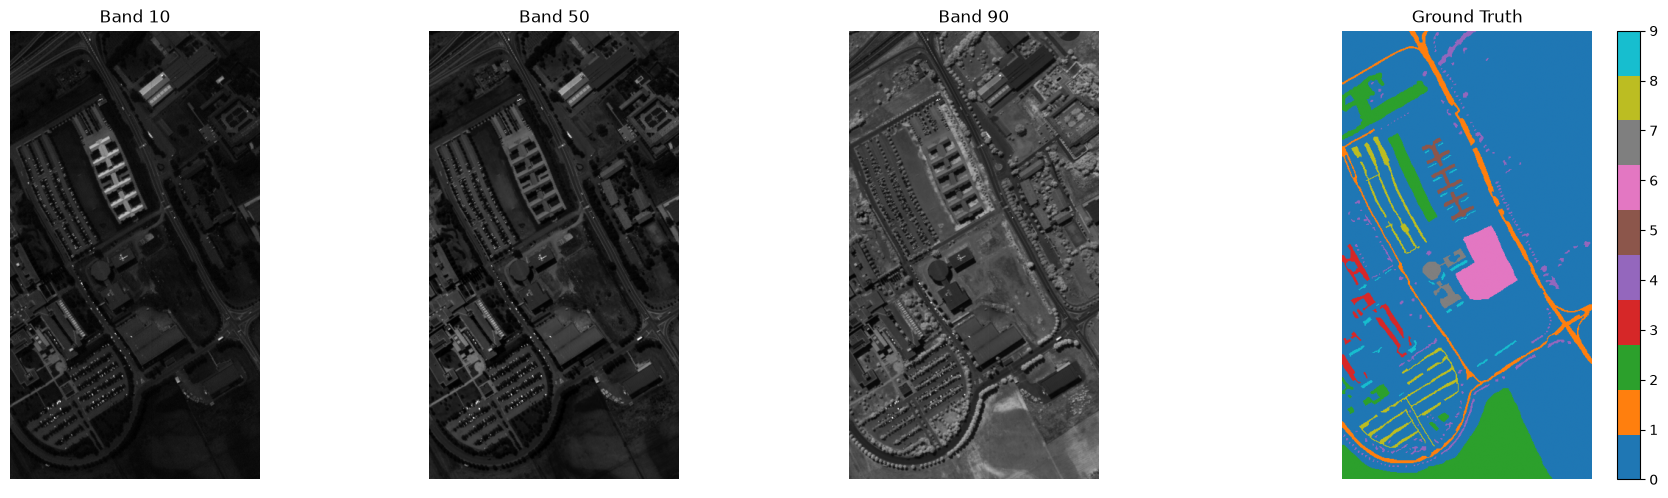

In [6]:
plot_spectral_bands_and_ground_truth(
    cube, ground_truth, BANDS_TO_SHOW, NUM_CLASSES
)

### Labeled Class Distribution

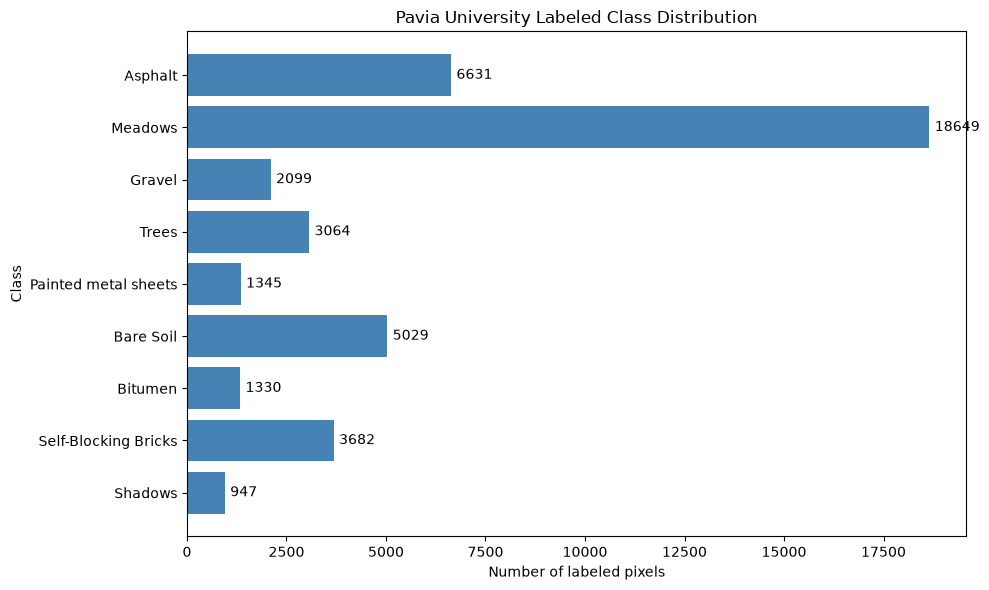

In [7]:
plot_class_distribution(labels, counts, class_names)

### Mean Spectral Signatures

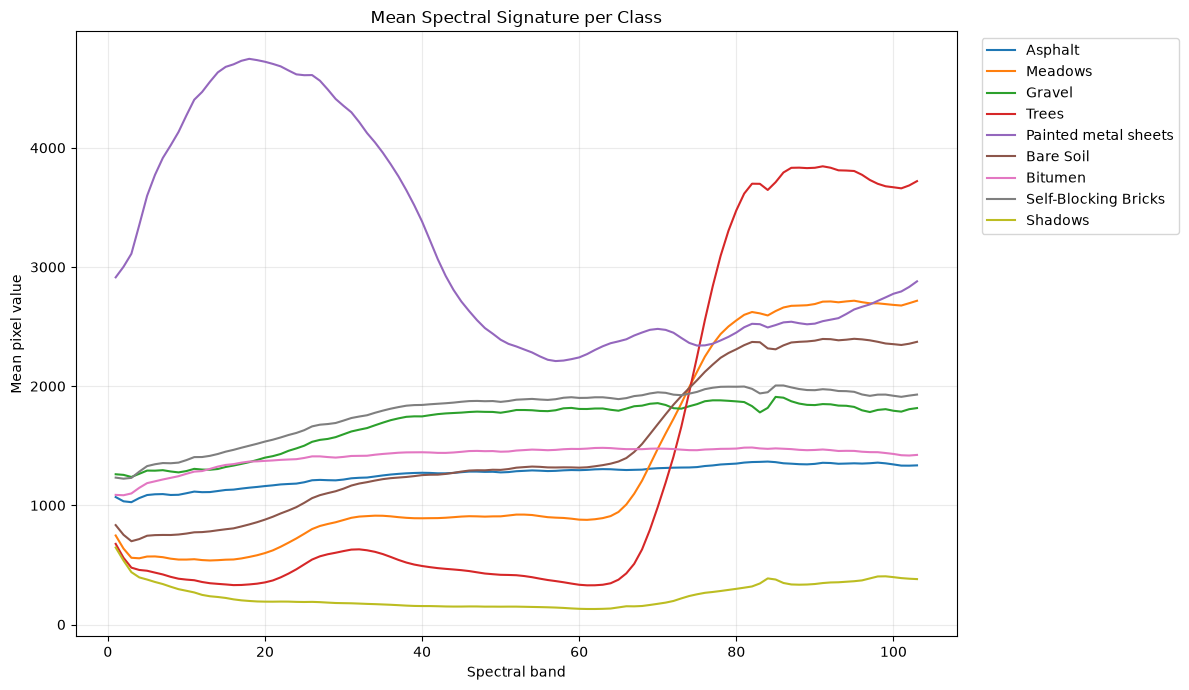

In [8]:
plot_mean_spectral_signatures(
    cube, ground_truth, LABELED_CLASS_IDS, class_names
)

### Coordinates By Class

In [9]:
coordinates_by_class = collect_coordinates_by_class(
    ground_truth, LABELED_CLASS_IDS
)

for label, coordinates in coordinates_by_class.items():
    expected_count = counts[labels == label].item()

    assert coordinates.shape == (expected_count, 2)
    print(
        f"{label}: {class_names[label]} - "
        f"{len(coordinates)} coordinates"
    )

total_coordinates = sum(
    len(coordinates)
    for coordinates in coordinates_by_class.values()
)

assert total_coordinates == np.count_nonzero(ground_truth)
print("Total labeled coordinates:", total_coordinates)

1: Asphalt - 6631 coordinates
2: Meadows - 18649 coordinates
3: Gravel - 2099 coordinates
4: Trees - 3064 coordinates
5: Painted metal sheets - 1345 coordinates
6: Bare Soil - 5029 coordinates
7: Bitumen - 1330 coordinates
8: Self-Blocking Bricks - 3682 coordinates
9: Shadows - 947 coordinates
Total labeled coordinates: 42776


### Few-Shot Coordinate Split

In [10]:
split_tables = create_few_shot_split(
    ground_truth,
    LABELED_CLASS_IDS,
    seed=SPLIT_SEED,
    train_samples_per_class=TRAIN_SAMPLES_PER_CLASS,
    validation_samples_per_class=VALIDATION_SAMPLES_PER_CLASS,
    split_type=DATA_SPLIT_TYPE,
    patch_radius=PATCH_RADIUS,
)
split_counts = split_counts_by_class(
    split_tables, LABELED_CLASS_IDS
)

for label in LABELED_CLASS_IDS:
    counts_for_label = split_counts[label]
    print(
        f"{label}: {class_names[label]} - "
        f"train {counts_for_label['train']}, "
        f"validation {counts_for_label['validation']}, "
        f"test {counts_for_label['test']}, "
        f"excluded {counts_for_label['excluded']}"
    )

1: Asphalt - train 10, validation 5, test 6616, excluded 0
2: Meadows - train 10, validation 5, test 18634, excluded 0
3: Gravel - train 10, validation 5, test 2084, excluded 0
4: Trees - train 10, validation 5, test 3049, excluded 0
5: Painted metal sheets - train 10, validation 5, test 1330, excluded 0
6: Bare Soil - train 10, validation 5, test 5014, excluded 0
7: Bitumen - train 10, validation 5, test 1315, excluded 0
8: Self-Blocking Bricks - train 10, validation 5, test 3667, excluded 0
9: Shadows - train 10, validation 5, test 932, excluded 0


### Split Verification

In [11]:
verify_few_shot_split(
    split_tables,
    ground_truth,
    LABELED_CLASS_IDS,
    train_samples_per_class=TRAIN_SAMPLES_PER_CLASS,
    validation_samples_per_class=VALIDATION_SAMPLES_PER_CLASS,
    split_type=DATA_SPLIT_TYPE,
    patch_radius=PATCH_RADIUS,
    class_names=class_names,
)
expected_train_samples = len(split_tables[SplitName.TRAIN.value])
expected_validation_samples = len(
    split_tables[SplitName.VALIDATION.value]
)
expected_test_samples = len(split_tables[SplitName.TEST.value])
expected_excluded_samples = len(
    split_tables[SplitName.EXCLUDED.value]
)

print("Train coordinates:", expected_train_samples)
print("Validation coordinates:", expected_validation_samples)
print("Test coordinates:", expected_test_samples)
print("Excluded coordinates:", expected_excluded_samples)
print("All split checks passed.")

Train coordinates: 90
Validation coordinates: 45
Test coordinates: 42641
Excluded coordinates: 0
All split checks passed.


### Save the Few-Shot Split

In [12]:
split_directory = project_root / "data" / "splits" / f"seed_{SPLIT_SEED}"
loaded_split_tables = save_and_verify_split(
    split_tables,
    ground_truth,
    split_directory,
    DATA_SPLIT_TYPE,
)

Saved 90 samples to c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\splits\seed_42\train.csv
Verified train.csv: 90 samples
Saved 45 samples to c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\splits\seed_42\validation.csv
Verified validation.csv: 45 samples
Saved 42641 samples to c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\splits\seed_42\test.csv
Verified test.csv: 42641 samples
Saved 0 samples to c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\splits\seed_42\excluded.csv
Verified excluded.csv: 0 samples


### Reload and Verify the Saved Split

In [13]:
for split_name, split_table in loaded_split_tables.items():
    print(f"{split_name}: {len(split_table)} saved samples")

print(f"Saved split verified successfully for seed {SPLIT_SEED}.")

train: 90 saved samples
validation: 45 saved samples
test: 42641 saved samples
excluded: 0 saved samples
Saved split verified successfully for seed 42.


### Border Analysis for Patch Extraction

In [14]:
padding_counts = count_padding_requirements(
    loaded_split_tables, ground_truth.shape, PATCH_RADIUS
)

for split_name, border_count in padding_counts.items():
    print(
        f"{split_name}: {border_count} of "
        f"{len(loaded_split_tables[split_name])} samples "
        "require padding"
    )

train: 3 of 90 samples require padding
validation: 1 of 45 samples require padding
test: 3297 of 42641 samples require padding
excluded: 0 of 0 samples require padding


### Per-Band Min-Max Normalization

In [15]:
normalized_cube, band_min, band_max = normalize_per_band_min_max(
    cube
)

assert normalized_cube.shape == cube.shape
assert normalized_cube.dtype == np.float32
assert not np.shares_memory(normalized_cube, cube)
assert np.allclose(normalized_cube.min(axis=(0, 1)), 0.0)
assert np.allclose(normalized_cube.max(axis=(0, 1)), 1.0)

print("Normalized cube shape:", normalized_cube.shape)
print("Normalized cube dtype:", normalized_cube.dtype)
print("Normalized range:", normalized_cube.min(), normalized_cube.max())
print("Raw cube remains unchanged:", cube.dtype, cube.min(), cube.max())

Normalized cube shape: (610, 340, 103)
Normalized cube dtype: float32
Normalized range: 0.0 1.0
Raw cube remains unchanged: uint16 0 8000


### Reflect Padding

In [16]:
original_cube_shape = cube.shape
original_cube_dtype = cube.dtype

padded_cube = reflect_pad_spatially(
    normalized_cube, PATCH_RADIUS
)

expected_padded_shape = (
    normalized_cube.shape[0] + 2 * PATCH_RADIUS,
    normalized_cube.shape[1] + 2 * PATCH_RADIUS,
    normalized_cube.shape[2],
)
restored_normalized_cube = padded_cube[
    PATCH_RADIUS:-PATCH_RADIUS,
    PATCH_RADIUS:-PATCH_RADIUS,
    :,
]

assert cube.shape == original_cube_shape
assert cube.dtype == original_cube_dtype
assert padded_cube.shape == expected_padded_shape
assert padded_cube.dtype == normalized_cube.dtype
assert not np.shares_memory(normalized_cube, padded_cube)
assert np.array_equal(restored_normalized_cube, normalized_cube)

print("Normalized cube shape:", normalized_cube.shape)
print("Padded cube shape:", padded_cube.shape)
print("Raw cube remains unchanged.")

Normalized cube shape: (610, 340, 103)
Padded cube shape: (624, 354, 103)
Raw cube remains unchanged.


### Single Patch Extraction Check

In [17]:
sample_row, sample_column, sample_label = loaded_split_tables[
    "train"
][0]

sample_row = int(sample_row)
sample_column = int(sample_column)
sample_label = int(sample_label)

sample_patch = extract_patch(
    padded_cube, sample_row, sample_column, PATCH_SIZE
)

expected_patch_shape = (int(PATCH_SIZE), int(PATCH_SIZE), cube.shape[2])
center_spectrum = sample_patch[PATCH_RADIUS, PATCH_RADIUS, :]

assert sample_patch.shape == expected_patch_shape
assert np.array_equal(
    center_spectrum,
    normalized_cube[sample_row, sample_column, :],
)
assert ground_truth[sample_row, sample_column] == sample_label
assert sample_label != 0

print("Coordinate:", (sample_row, sample_column))
print("Target:", sample_label, class_names[sample_label])
print("Patch shape:", sample_patch.shape)
print("Center pixel and target verified.")

Coordinate: (229, 29)
Target: 1 Asphalt
Patch shape: (15, 15, 103)
Center pixel and target verified.


### Reusable Patch Extraction

In [18]:
all_saved_samples = np.vstack(list(loaded_split_tables.values()))
saved_rows = all_saved_samples[:, 0]
saved_columns = all_saved_samples[:, 1]

border_mask = (
    (saved_rows < PATCH_RADIUS)
    | (saved_rows >= ground_truth.shape[0] - PATCH_RADIUS)
    | (saved_columns < PATCH_RADIUS)
    | (saved_columns >= ground_truth.shape[1] - PATCH_RADIUS)
)
border_row, border_column, border_label = all_saved_samples[border_mask][0]
border_row = int(border_row)
border_column = int(border_column)
border_label = int(border_label)

border_patch = extract_patch(
    padded_cube, border_row, border_column, PATCH_SIZE
)
border_center = border_patch[PATCH_RADIUS, PATCH_RADIUS, :]

assert border_patch.shape == (
    int(PATCH_SIZE),
    int(PATCH_SIZE),
    cube.shape[2],
)
assert np.array_equal(
    border_center,
    normalized_cube[border_row, border_column, :],
)
assert ground_truth[border_row, border_column] == border_label

print("Border coordinate:", (border_row, border_column))
print("Target:", border_label, class_names[border_label])
print("Patch shape:", border_patch.shape)
print("Border patch verified.")

Border coordinate: (69, 2)
Target: 1 Asphalt
Patch shape: (15, 15, 103)
Border patch verified.


### PyTorch Patch Dataset

This portion of the code reads the CSV file with the saved split and from the normalized and padded data, estracts patch of the wanted size, adjust for model class logits.

We also convert numeric types to float32 and we use *ascontigousarray* for efficiency

In [19]:
datasets = create_patch_datasets(
    padded_cube, loaded_split_tables, PATCH_SIZE, NUM_CLASSES
)
train_dataset = datasets[SplitName.TRAIN.value]
validation_dataset = datasets[SplitName.VALIDATION.value]
test_dataset = datasets[SplitName.TEST.value]

example_patch, example_target = train_dataset[0]
example_row, example_column = train_dataset.coordinates[0]

assert len(train_dataset) == expected_train_samples
assert len(validation_dataset) == expected_validation_samples
assert len(test_dataset) == expected_test_samples
assert example_patch.shape == (
    cube.shape[2], int(PATCH_SIZE), int(PATCH_SIZE)
)
assert example_patch.dtype == torch.float32
assert example_target.dtype == torch.long
assert torch.equal(
    example_patch[:, PATCH_RADIUS, PATCH_RADIUS],
    torch.from_numpy(
        normalized_cube[example_row, example_column, :]
    ),
)

print("Dataset sizes:", len(train_dataset), len(validation_dataset), len(test_dataset))
print("Patch tensor shape:", tuple(example_patch.shape))
print("Target index:", example_target.item())
print("Original class label:", example_target.item() + 1)

Dataset sizes: 90 45 42641
Patch tensor shape: (103, 15, 15)
Target index: 0
Original class label: 1


### PyTorch DataLoaders

In [20]:
dataloaders = create_dataloaders(
    datasets,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    training_seed=TRAINING_SEED,
)
train_loader = dataloaders[SplitName.TRAIN.value]
validation_loader = dataloaders[SplitName.VALIDATION.value]
test_loader = dataloaders[SplitName.TEST.value]

batch_patches, batch_targets = next(iter(validation_loader))
train_class_counts = np.bincount(
    train_dataset.targets, minlength=NUM_CLASSES
)

assert batch_patches.shape == (
    BATCH_SIZE, cube.shape[2], int(PATCH_SIZE), int(PATCH_SIZE)
)
assert batch_targets.shape == (BATCH_SIZE,)
assert batch_patches.dtype == torch.float32
assert batch_targets.dtype == torch.long
assert batch_targets.min() >= 0
assert batch_targets.max() < NUM_CLASSES
assert np.array_equal(
    train_class_counts,
    np.full(NUM_CLASSES, TRAIN_SAMPLES_PER_CLASS),
)

print("Batch shape:", tuple(batch_patches.shape))
print("Target shape:", tuple(batch_targets.shape))
print("Batches per epoch:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))
print("Training samples per class:", train_class_counts.tolist())

Batch shape: (32, 103, 15, 15)
Target shape: (32,)
Batches per epoch: 3
Validation batches: 2
Test batches: 1333
Training samples per class: [10, 10, 10, 10, 10, 10, 10, 10, 10]


## Model Architecture

### CNN, Transformer, CT and CSA Shape Checks

The CNN branch returns only its fused multiscale features. The single CT residual is applied after CNN-Transformer fusion, as shown in the paper. CNN-only models apply the equivalent residual around their standalone CNN block. For spatial attention, this notebook follows the detailed text in Section 2.4: an extrema branch (`max`, `min`) and a distribution branch (`mean`, `std`) use `5 x 5` convolutions and PReLU, followed by concatenation and a `1 x 1` fusion convolution. Every block preserves `(B, C, H, W)`.

In [21]:
cnn_block = MultiscaleCNNBlock(FEATURE_CHANNELS)
cnn_block.eval()

dummy_features = torch.randn(
    2, FEATURE_CHANNELS, int(PATCH_SIZE), int(PATCH_SIZE)
)
transformer_branch = TransformerBranch(
    FEATURE_CHANNELS,
    PATCH_SIZE,
    num_heads=TRANSFORMER_HEADS,
    expansion_factor=TRANSFORMER_FFN_EXPANSION,
    dropout=TRANSFORMER_DROPOUT,
    ffn_residual_scale=TRANSFORMER_FFN_RESIDUAL_SCALE,
    position_encoding=TRANSFORMER_POSITION_ENCODING,
    cnn_normalization=TRANSFORMER_CNN_NORMALIZATION,
)
transformer_branch.eval()
ct_block = CTBlock(
    FEATURE_CHANNELS,
    PATCH_SIZE,
    transformer_heads=TRANSFORMER_HEADS,
    transformer_expansion_factor=TRANSFORMER_FFN_EXPANSION,
    transformer_dropout=TRANSFORMER_DROPOUT,
    transformer_ffn_residual_scale=TRANSFORMER_FFN_RESIDUAL_SCALE,
    transformer_position_encoding=TRANSFORMER_POSITION_ENCODING,
    transformer_cnn_normalization=TRANSFORMER_CNN_NORMALIZATION,
)
ct_block.eval()
channel_attention = ChannelAttention()
channel_attention.eval()
spatial_attention = SpatialAttention()
spatial_attention.eval()
csa_block = ChannelSpatialAttentionBlock()
csa_block.eval()

with torch.no_grad():
    cnn_output = cnn_block(dummy_features)
    transformer_output = transformer_branch(dummy_features)
    ct_output = ct_block(dummy_features)
    channel_attention_output = channel_attention(dummy_features)
    spatial_attention_output = spatial_attention(dummy_features)
    csa_output = csa_block(dummy_features)

assert cnn_output.shape == dummy_features.shape
assert transformer_output.shape == dummy_features.shape
assert ct_output.shape == dummy_features.shape
assert channel_attention_output.shape == dummy_features.shape
assert spatial_attention_output.shape == dummy_features.shape
assert csa_output.shape == dummy_features.shape

print("Input shape:", tuple(dummy_features.shape))
print("CNN output shape:", tuple(cnn_output.shape))
print("Transformer output shape:", tuple(transformer_output.shape))
print("CT output shape:", tuple(ct_output.shape))
print("Channel attention shape:", tuple(channel_attention_output.shape))
print("Spatial attention shape:", tuple(spatial_attention_output.shape))
print("CSA output shape:", tuple(csa_output.shape))
print("All feature blocks preserve channel and spatial dimensions.")

Input shape: (2, 256, 15, 15)
CNN output shape: (2, 256, 15, 15)
Transformer output shape: (2, 256, 15, 15)
CT output shape: (2, 256, 15, 15)
Channel attention shape: (2, 256, 15, 15)
Spatial attention shape: (2, 256, 15, 15)
CSA output shape: (2, 256, 15, 15)
All feature blocks preserve channel and spatial dimensions.


### Selected Classifier

In [22]:
selected_model = build_model(
    ARCHITECTURE,
    input_channels=cube.shape[2],
    feature_channels=FEATURE_CHANNELS,
    num_classes=NUM_CLASSES,
    patch_size=PATCH_SIZE,
    transformer_heads=TRANSFORMER_HEADS,
    transformer_expansion_factor=TRANSFORMER_FFN_EXPANSION,
    transformer_dropout=TRANSFORMER_DROPOUT,
    transformer_ffn_residual_scale=TRANSFORMER_FFN_RESIDUAL_SCALE,
    transformer_position_encoding=TRANSFORMER_POSITION_ENCODING,
    transformer_cnn_normalization=TRANSFORMER_CNN_NORMALIZATION,
)
selected_model.eval()

example_batch = example_patch.unsqueeze(0)
with torch.no_grad():
    projected_features = selected_model.input_projection(example_batch)
    example_logits = selected_model(example_batch)

assert projected_features.shape == (
    1, FEATURE_CHANNELS, int(PATCH_SIZE), int(PATCH_SIZE)
)
assert example_logits.shape == (1, NUM_CLASSES)

print("Input shape:", tuple(example_batch.shape))
print("Architecture:", ARCHITECTURE.display_name)
print("Projected feature shape:", tuple(projected_features.shape))
print("Logits shape:", tuple(example_logits.shape))

Input shape: (1, 103, 15, 15)
Architecture: CNN-Transformer-CSA
Projected feature shape: (1, 256, 15, 15)
Logits shape: (1, 9)


### Forward and Backward Sanity Check

In [23]:
sanity_indices = [
    np.flatnonzero(train_dataset.targets == class_index)[0]
    for class_index in range(NUM_CLASSES)
]
sanity_samples = [
    train_dataset[int(index)] for index in sanity_indices
]
sanity_patches = torch.stack([sample[0] for sample in sanity_samples])
sanity_targets = torch.stack([sample[1] for sample in sanity_samples])

torch.manual_seed(TRAINING_SEED)
sanity_model = build_model(
    ARCHITECTURE,
    input_channels=cube.shape[2],
    feature_channels=FEATURE_CHANNELS,
    num_classes=NUM_CLASSES,
    patch_size=PATCH_SIZE,
    transformer_heads=TRANSFORMER_HEADS,
    transformer_expansion_factor=TRANSFORMER_FFN_EXPANSION,
    transformer_dropout=TRANSFORMER_DROPOUT,
    transformer_ffn_residual_scale=TRANSFORMER_FFN_RESIDUAL_SCALE,
    transformer_position_encoding=TRANSFORMER_POSITION_ENCODING,
    transformer_cnn_normalization=TRANSFORMER_CNN_NORMALIZATION,
)
sanity_model.train()

criterion = nn.CrossEntropyLoss()
sanity_logits = sanity_model(sanity_patches)
sanity_loss = criterion(sanity_logits, sanity_targets)
sanity_loss.backward()

gradients = [
    parameter.grad
    for parameter in sanity_model.parameters()
    if parameter.grad is not None
]
gradient_norm = sum(gradient.norm().item() for gradient in gradients)

assert sanity_patches.shape == (
    NUM_CLASSES, cube.shape[2], int(PATCH_SIZE), int(PATCH_SIZE)
)
assert torch.equal(sanity_targets, torch.arange(NUM_CLASSES))
assert sanity_logits.shape == (NUM_CLASSES, NUM_CLASSES)
assert torch.isfinite(sanity_loss)
assert gradients
assert all(torch.isfinite(gradient).all() for gradient in gradients)
assert gradient_norm > 0

sanity_model.zero_grad(set_to_none=True)

print("Sanity batch shape:", tuple(sanity_patches.shape))
print("Targets:", sanity_targets.tolist())
print("Logits shape:", tuple(sanity_logits.shape))
print("Loss:", sanity_loss.item())
print("Gradient norm:", gradient_norm)
print("Forward and backward checks passed.")

Sanity batch shape: (9, 103, 15, 15)
Targets: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Logits shape: (9, 9)
Loss: 2.296941041946411
Gradient norm: 24.684228424674505
Forward and backward checks passed.


### Optional Small-Batch Overfitting Test

This diagnostic is controlled by `RUN_SMALL_BATCH_OVERFIT_TEST`. It is skipped by default because BatchNorm running statistics make its final evaluation unsuitable for the CT architecture.

In [24]:
if RUN_SMALL_BATCH_OVERFIT_TEST:
    torch.manual_seed(TRAINING_SEED)
    overfit_model = build_model(
        ARCHITECTURE,
        input_channels=cube.shape[2],
        feature_channels=FEATURE_CHANNELS,
        num_classes=NUM_CLASSES,
        patch_size=PATCH_SIZE,
        transformer_heads=TRANSFORMER_HEADS,
        transformer_expansion_factor=TRANSFORMER_FFN_EXPANSION,
        transformer_dropout=TRANSFORMER_DROPOUT,
        transformer_ffn_residual_scale=TRANSFORMER_FFN_RESIDUAL_SCALE,
        transformer_position_encoding=TRANSFORMER_POSITION_ENCODING,
        transformer_cnn_normalization=TRANSFORMER_CNN_NORMALIZATION,
    )
    overfit_result = run_small_batch_overfit_check(
        overfit_model,
        sanity_patches,
        sanity_targets,
        learning_rate=OVERFIT_LEARNING_RATE,
        min_steps=OVERFIT_MIN_STEPS,
        max_steps=OVERFIT_MAX_STEPS,
        target_loss=OVERFIT_TARGET_LOSS,
    )

    print("Steps:", overfit_result["steps"])
    print("Initial loss:", overfit_result["initial_loss"])
    print("Final loss:", overfit_result["final_loss"])
    print("Final accuracy:", overfit_result["final_accuracy"])
    print("Small-batch overfitting test passed.")
else:
    print("Small-batch overfitting test skipped.")

Small-batch overfitting test skipped.


## Model Training

### Training Configuration

In [25]:
device = configure_reproducibility(TRAINING_SEED)

model = build_model(
    ARCHITECTURE,
    input_channels=cube.shape[2],
    feature_channels=FEATURE_CHANNELS,
    num_classes=NUM_CLASSES,
    patch_size=PATCH_SIZE,
    transformer_heads=TRANSFORMER_HEADS,
    transformer_expansion_factor=TRANSFORMER_FFN_EXPANSION,
    transformer_dropout=TRANSFORMER_DROPOUT,
    transformer_ffn_residual_scale=TRANSFORMER_FFN_RESIDUAL_SCALE,
    transformer_position_encoding=TRANSFORMER_POSITION_ENCODING,
    transformer_cnn_normalization=TRANSFORMER_CNN_NORMALIZATION,
).to(device)
model_name = ARCHITECTURE.display_name
run_name = (
    RunMode.FULL.value
    if RUN_FULL_TRAINING
    else RunMode.SMOKE.value
)
epochs_to_run = (
    EPOCHS if RUN_FULL_TRAINING else SMOKE_TEST_EPOCHS
)
checkpoint_path = build_checkpoint_path(
    project_root / "outputs" / "checkpoints",
    architecture=ARCHITECTURE,
    transformer_heads=TRANSFORMER_HEADS,
    transformer_expansion_factor=TRANSFORMER_FFN_EXPANSION,
    transformer_dropout=TRANSFORMER_DROPOUT,
    transformer_ffn_residual_scale=TRANSFORMER_FFN_RESIDUAL_SCALE,
    transformer_position_encoding=TRANSFORMER_POSITION_ENCODING,
    transformer_cnn_normalization=TRANSFORMER_CNN_NORMALIZATION,
    model_variant=MODEL_VARIANT,
    run_name=run_name,
    patch_size=PATCH_SIZE,
    epochs=epochs_to_run,
    feature_channels=FEATURE_CHANNELS,
    scheduling_type=LR_SCHEDULING,
    split_seed=SPLIT_SEED,
    split_type=DATA_SPLIT_TYPE,
    training_seed=TRAINING_SEED,
)
experiment_configuration = {
    "dataset": "Pavia University",
    "model": model.__class__.__name__,
    "architecture": ARCHITECTURE.value,
    "model_variant": MODEL_VARIANT,
    "split_seed": SPLIT_SEED,
    "data_split_type": DATA_SPLIT_TYPE.value,
    "training_seed": TRAINING_SEED,
    "feature_channels": FEATURE_CHANNELS,
    "transformer_heads": (
        TRANSFORMER_HEADS
        if ARCHITECTURE.uses_transformer
        else None
    ),
    "transformer_ffn_expansion": (
        TRANSFORMER_FFN_EXPANSION
        if ARCHITECTURE.uses_transformer
        else None
    ),
    "transformer_ffn_residual_scale": (
        TRANSFORMER_FFN_RESIDUAL_SCALE
        if ARCHITECTURE.uses_transformer
        else None
    ),
    "transformer_position_encoding": (
        TRANSFORMER_POSITION_ENCODING.value
        if ARCHITECTURE.uses_transformer
        else None
    ),
    "transformer_cnn_normalization": (
        TRANSFORMER_CNN_NORMALIZATION.value
        if ARCHITECTURE.uses_transformer
        else None
    ),
    "transformer_dropout": (
        TRANSFORMER_DROPOUT
        if ARCHITECTURE.uses_transformer
        else None
    ),
    "patch_size": int(PATCH_SIZE),
    "num_classes": NUM_CLASSES,
    "run_mode": run_name,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "lr_scheduling": LR_SCHEDULING.value,
    "epochs_requested": epochs_to_run,
    "normalization": "per_band_min_max_full_scene",
    "padding": "reflect",
}
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Device:", device)
print("Architecture:", model_name)
print("Model variant:", MODEL_VARIANT)
if ARCHITECTURE.uses_transformer:
    print("Transformer heads:", TRANSFORMER_HEADS)
    print(
        "Transformer FFN residual scale:",
        TRANSFORMER_FFN_RESIDUAL_SCALE,
    )
    print(
        "Transformer position encoding:",
        TRANSFORMER_POSITION_ENCODING.value,
    )
    print(
        "Transformer CNN normalization:",
        TRANSFORMER_CNN_NORMALIZATION.value,
    )
print("Epochs:", epochs_to_run)
print("Learning rate:", LEARNING_RATE)
print("LR scheduling:", LR_SCHEDULING.value)
print("Data split:", DATA_SPLIT_TYPE.value)
print("Trainable parameters:", trainable_parameters)
print("Checkpoint:", checkpoint_path)

Device: cpu
Architecture: CNN-Transformer-CSA
Model variant: outer_residual_conformer_rpe
Transformer heads: 4
Transformer FFN residual scale: 0.5
Transformer position encoding: learned_2d
Epochs: 150
Learning rate: 8e-05
LR scheduling: fixed
Data split: random
Trainable parameters: 5551259
Checkpoint: c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\outputs\checkpoints\cnn_transformer_csa_outer_residual_conformer_rpe_h4_x4_d0p1_full_p15_e150_f256_lrfixed_split42_random_train100.pt


### Model Training

In [26]:
training_result = fit_model(
    model,
    train_loader,
    validation_loader,
    device,
    epochs=epochs_to_run,
    learning_rate=LEARNING_RATE,
    scheduling_type=LR_SCHEDULING,
    checkpoint_path=checkpoint_path,
    checkpoint_metadata=experiment_configuration,
)
history = training_result["history"]

print("Best epoch:", training_result["best_epoch"])
print(
    "Best validation loss:",
    training_result["best_validation_loss"],
)
print("Checkpoint saved to:", checkpoint_path)

Epoch 001/150 | train loss 2.1610, acc 0.1889 | val loss 2.0972, acc 0.1556 | lr 8.00e-05
Epoch 010/150 | train loss 0.6215, acc 0.7889 | val loss 1.7976, acc 0.2889 | lr 8.00e-05
Epoch 020/150 | train loss 0.2783, acc 0.9111 | val loss 0.7555, acc 0.6667 | lr 8.00e-05
Epoch 030/150 | train loss 0.1062, acc 0.9778 | val loss 0.6825, acc 0.7778 | lr 8.00e-05
Epoch 040/150 | train loss 0.0414, acc 1.0000 | val loss 0.8513, acc 0.7111 | lr 8.00e-05
Epoch 050/150 | train loss 0.0326, acc 0.9889 | val loss 0.5859, acc 0.8444 | lr 8.00e-05
Epoch 060/150 | train loss 0.0324, acc 0.9889 | val loss 0.9787, acc 0.7111 | lr 8.00e-05
Epoch 070/150 | train loss 0.0225, acc 1.0000 | val loss 1.2065, acc 0.7111 | lr 8.00e-05
Epoch 080/150 | train loss 0.0179, acc 1.0000 | val loss 1.3287, acc 0.7333 | lr 8.00e-05
Epoch 090/150 | train loss 0.0146, acc 1.0000 | val loss 0.8212, acc 0.7778 | lr 8.00e-05
Epoch 100/150 | train loss 0.0121, acc 1.0000 | val loss 0.8208, acc 0.8222 | lr 8.00e-05
Epoch 110/

### Training Curves

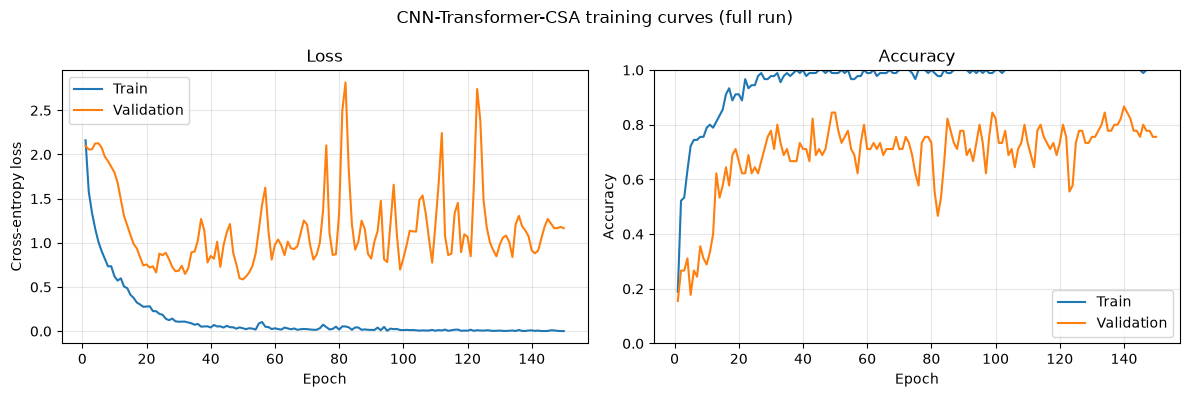

In [27]:
plot_training_curves(history, run_name, model_name)

## Model Evaluation

In [28]:
evaluation_result = evaluate_checkpoint(
    model,
    test_loader,
    checkpoint_path,
    device,
    NUM_CLASSES,
    progress_every=EVALUATION_PROGRESS_EVERY,
    progress_label="Test evaluation",
)
best_checkpoint = evaluation_result["checkpoint"]
test_targets = evaluation_result["targets"]
test_predictions = evaluation_result["predictions"]

assert len(test_targets) == len(test_dataset)
print("Loaded checkpoint epoch:", best_checkpoint["epoch"])
print("Checkpoint validation loss:", best_checkpoint["validation_loss"])
print("Test predictions:", len(test_predictions))

Test evaluation: batch 1/1333 | samples 32/42641
Test evaluation: batch 100/1333 | samples 3200/42641
Test evaluation: batch 200/1333 | samples 6400/42641
Test evaluation: batch 300/1333 | samples 9600/42641
Test evaluation: batch 400/1333 | samples 12800/42641
Test evaluation: batch 500/1333 | samples 16000/42641
Test evaluation: batch 600/1333 | samples 19200/42641
Test evaluation: batch 700/1333 | samples 22400/42641
Test evaluation: batch 800/1333 | samples 25600/42641
Test evaluation: batch 900/1333 | samples 28800/42641
Test evaluation: batch 1000/1333 | samples 32000/42641
Test evaluation: batch 1100/1333 | samples 35200/42641
Test evaluation: batch 1200/1333 | samples 38400/42641
Test evaluation: batch 1300/1333 | samples 41600/42641
Test evaluation: batch 1333/1333 | samples 42641/42641
Loaded checkpoint epoch: 50
Checkpoint validation loss: 0.5859224081039429
Test predictions: 42641


### Test Metrics

OA: 0.8053
AA: 0.8571
Kappa: 0.7550
Per-class accuracy:
  1 Asphalt: 0.7758
  2 Meadows: 0.7282
  3 Gravel: 0.6464
  4 Trees: 0.9118
  5 Painted metal sheets: 0.9338
  6 Bare Soil: 0.9659
  7 Bitumen: 0.8791
  8 Self-Blocking Bricks: 0.9231
  9 Shadows: 0.9496
Evaluation report saved to: c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\outputs\results\cnn_transformer_csa_outer_residual_conformer_rpe_h4_x4_d0p1_full_p15_e150_f256_lrfixed_split42_random_train100.json


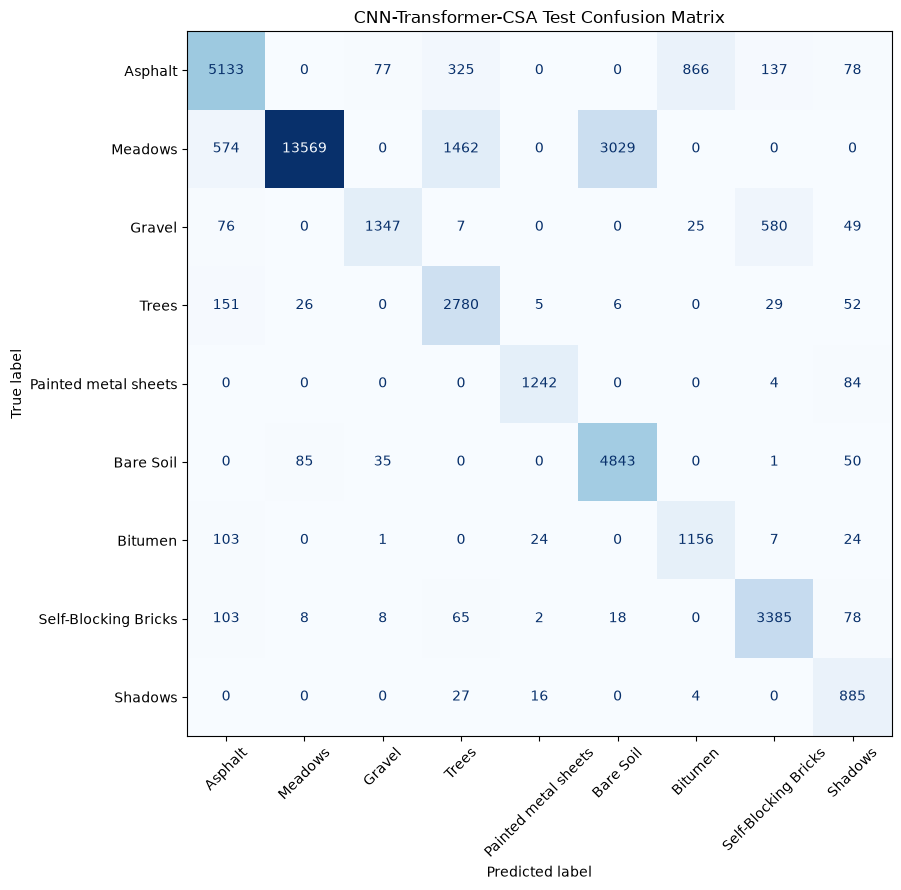

In [29]:
test_metrics = evaluation_result["metrics"]
confusion = test_metrics["confusion_matrix"]
per_class_accuracy = test_metrics["per_class_accuracy"]
overall_accuracy = test_metrics["overall_accuracy"]
average_accuracy = test_metrics["average_accuracy"]
kappa = test_metrics["kappa"]

print(f"OA: {overall_accuracy:.4f}")
print(f"AA: {average_accuracy:.4f}")
print(f"Kappa: {kappa:.4f}")
print("Per-class accuracy:")
for class_index, class_accuracy in enumerate(per_class_accuracy):
    original_label = class_index + 1
    print(
        f"  {original_label} {class_names[original_label]}: "
        f"{class_accuracy:.4f}"
    )

evaluation_report_path = (
    project_root / "outputs" / "results"
    / f"{checkpoint_path.stem}.json"
)
evaluation_report = build_evaluation_report(
    experiment_configuration,
    checkpoint_path,
    evaluation_result,
    class_names,
)
if SAVE_EVALUATION_REPORT:
    save_evaluation_report(
        evaluation_report_path, evaluation_report
    )
    print("Evaluation report saved to:", evaluation_report_path)

display_names = [class_names[label] for label in LABELED_CLASS_IDS]
plot_confusion_matrix(confusion, display_names, model_name)

### Normalized Confusion Matrix

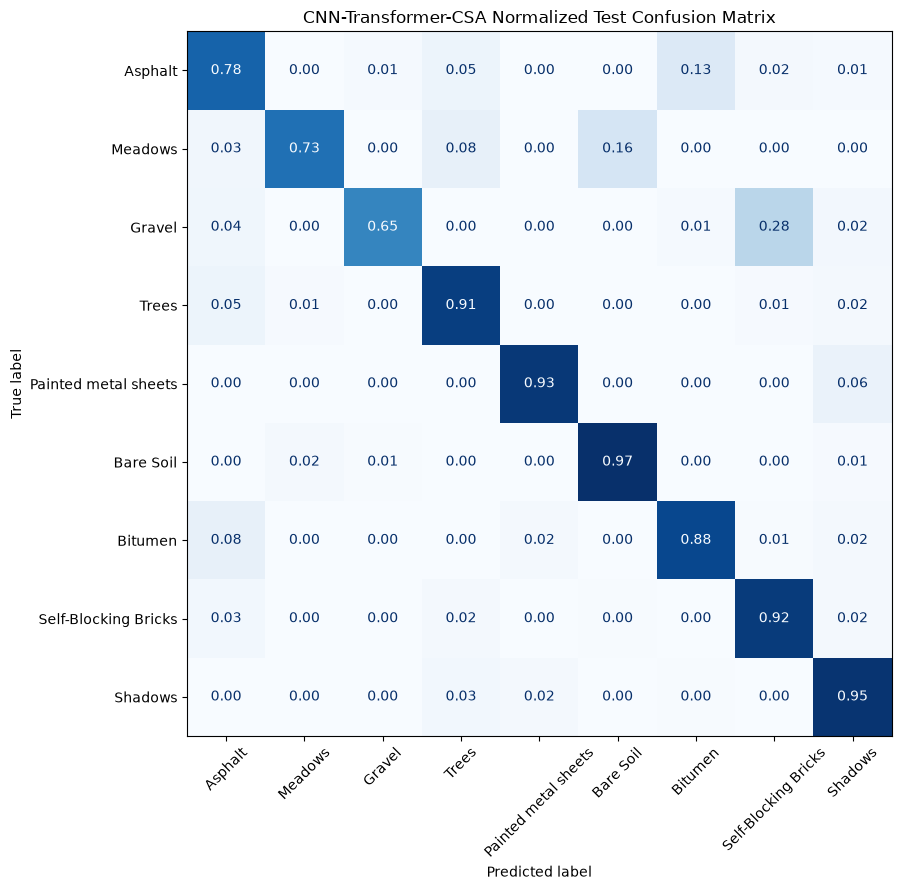

In [30]:
plot_confusion_matrix(
    confusion, display_names, model_name, normalized=True
)

### Classification Map

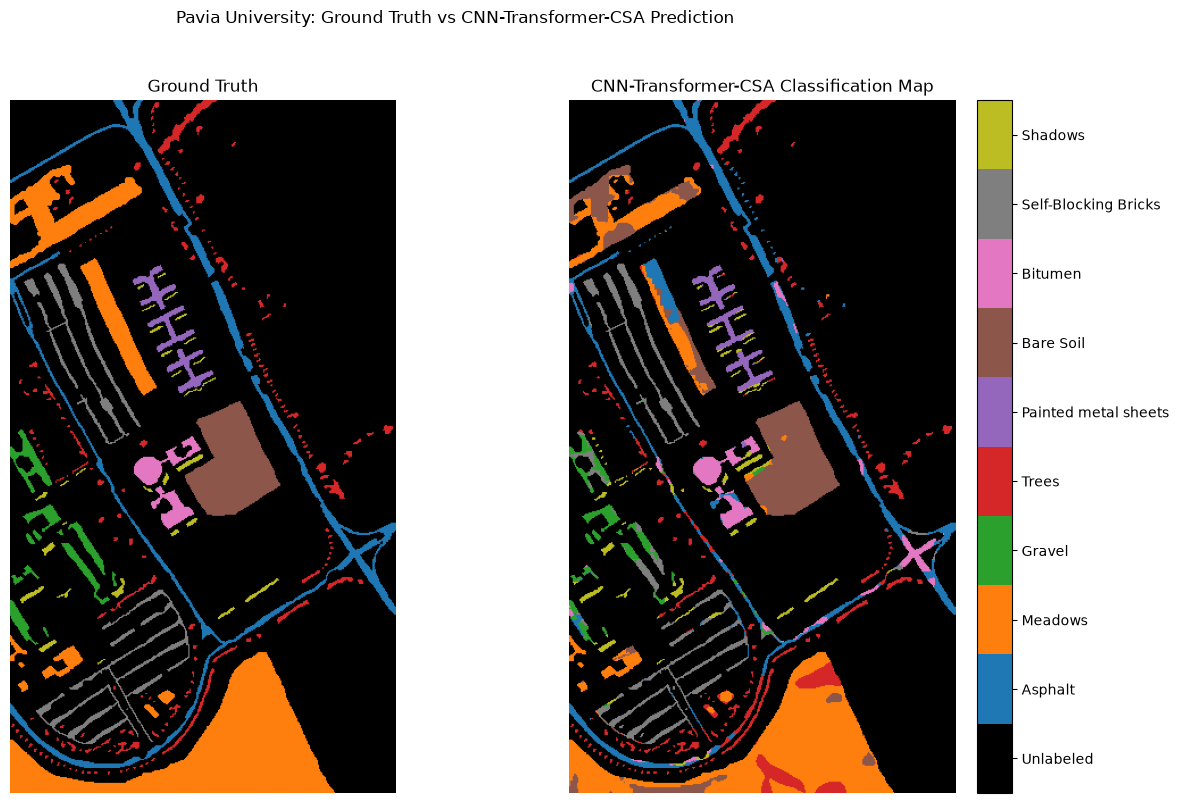

Mapped labeled pixels: 42776
Unlabeled pixels kept as background: 164624


In [31]:
classification_map = build_classification_map(
    model,
    device,
    ground_truth,
    padded_cube,
    loaded_split_tables,
    test_predictions,
    patch_size=PATCH_SIZE,
    num_classes=NUM_CLASSES,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
labeled_mask = ground_truth != PaviaClass.UNLABELED
plot_classification_map(
    ground_truth,
    classification_map,
    class_names,
    NUM_CLASSES,
    model_name,
)

print("Mapped labeled pixels:", np.count_nonzero(labeled_mask))
print("Unlabeled pixels kept as background:", (~labeled_mask).sum())